In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/ckskaggle/eda-de/__results__.html
/kaggle/input/notebooks/ckskaggle/eda-de/__notebook__.ipynb
/kaggle/input/notebooks/ckskaggle/eda-de/__output__.json
/kaggle/input/notebooks/ckskaggle/eda-de/custom.css
/kaggle/input/notebooks/ckskaggle/eda-de/csv_exports/ML_Engineered_Battery_Dataset_RUL.csv
/kaggle/input/notebooks/ckskaggle/eda-de/csv_exports/ML_Engineered_Battery_Dataset.csv
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___9_0.png
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___19_0.png
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___21_0.png
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___17_0.png
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___13_0.png
/kaggle/input/notebooks/ckskaggle/eda-de/__results___files/__results___26_0.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error

sns.set_theme(style="whitegrid")

In [4]:

# ==========================================
# 1. LOAD DATA & DEFINE STRATIFIED LOBO SPLIT
# ==========================================
path = '/kaggle/input/notebooks/ckskaggle/eda-de/csv_exports/ML_Engineered_Battery_Dataset.csv'
df = pd.read_csv(path)

# The 9 test batteries (1 from each condition group)
test_batteries = ['B0005', 'B0025', 'B0029', 'B0033', 'B0038', 'B0041', 'B0045', 'B0049', 'B0053']

# Split data: If Battery_ID is in the list -> Test Set. Otherwise -> Train Set.
df_train = df[~df['Battery_ID'].isin(test_batteries)].copy()
df_test = df[df['Battery_ID'].isin(test_batteries)].copy()

# Features (X) and Target (y)
features = [
    'Cycle_Index', 'Ambient_Temperature', 'Discharge_Time_Seconds', 
    'Max_Temp_Reached', 'Min_Voltage_Recorded', 
    'Voltage_Drop_Rate_V_per_sec', 'Internal_Resistance_Re'
]
target = 'SoH'

X_train, y_train = df_train[features], df_train[target]
X_test, y_test = df_test[features], df_test[target]

print(f"Training on {len(df_train['Battery_ID'].unique())} batteries ({len(X_train)} cycles)")
print(f"Testing on {len(df_test['Battery_ID'].unique())} unseen batteries ({len(X_test)} cycles)")


Training on 25 batteries (2069 cycles)
Testing on 9 unseen batteries (700 cycles)


In [6]:
# ==========================================
# 2. TRAIN THE MODELS
# ==========================================
print("\nTraining Track A Models...")

# Model 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)

rf_model.fit(X_train, y_train)


Training Track A Models...
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    0.2s


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished


RandomForestRegressor(n_jobs=-1, random_state=42, verbose=2)

In [7]:
# Model 2: XGBoost (Using Kaggle GPU)
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, tree_method='hist', device='cuda', random_state=42)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:

# Model 3: LightGBM (CPU is extremely fast, but can use device_type='gpu' if configured)
lgb_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 2069, number of used features: 7
[LightGBM] [Info] Start training from score 1.330906


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [11]:
# ==========================================
# 3. BENCHMARK COMPARISON ON UNSEEN BATTERY
# ==========================================
# Let's test them on Battery B0005 (Room Temp, 2A)
target_test_battery = 'B0005'
df_b0005 = df_test[df_test['Battery_ID'] == target_test_battery].copy()
X_b0005 = df_b0005[features]

# Generate Predictions
df_b0005['Pred_RF'] = rf_model.predict(X_b0005)
df_b0005['Pred_XGB'] = xgb_model.predict(X_b0005)
df_b0005['Pred_LGBM'] = lgb_model.predict(X_b0005)





[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


In [12]:
# Calculate RMSE for each model
rmse_rf = root_mean_squared_error(df_b0005['SoH'], df_b0005['Pred_RF'])
rmse_xgb = root_mean_squared_error(df_b0005['SoH'], df_b0005['Pred_XGB'])
rmse_lgbm = root_mean_squared_error(df_b0005['SoH'], df_b0005['Pred_LGBM'])

print(f"\n--- RMSE on Unseen Battery {target_test_battery} ---")
print(f"Random Forest: {rmse_rf:.4f}")
print(f"XGBoost:       {rmse_xgb:.4f}")
print(f"LightGBM:      {rmse_lgbm:.4f}")



--- RMSE on Unseen Battery B0005 ---
Random Forest: 0.0331
XGBoost:       0.0774
LightGBM:      0.0595


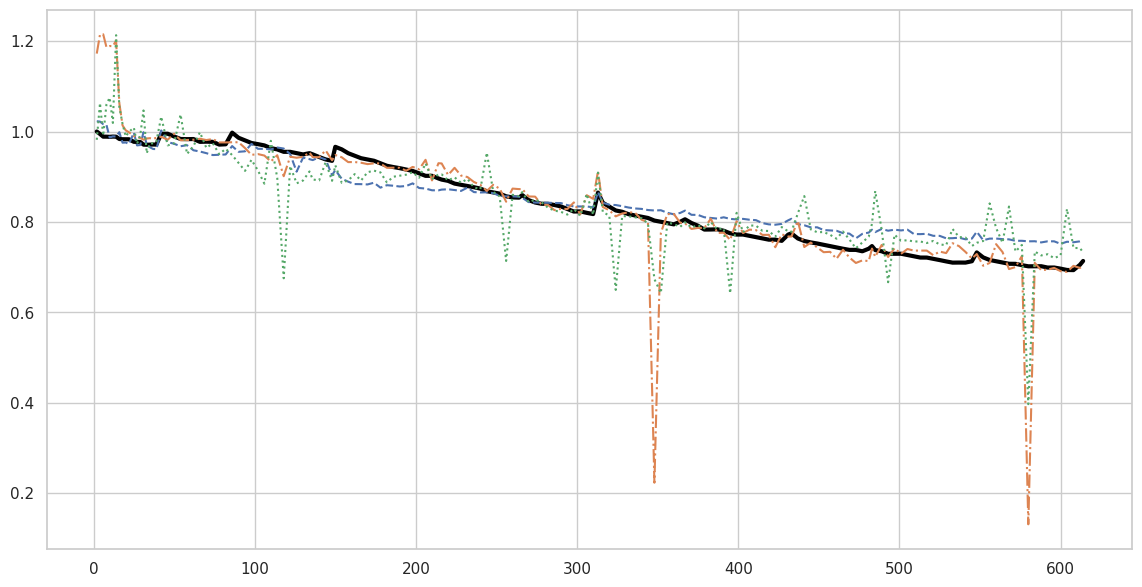

In [13]:
# Plotting the Results
plt.figure(figsize=(14, 7))
plt.plot(df_b0005['Cycle_Index'], df_b0005['SoH'], label='Actual SoH (Ground Truth)', color='black', linewidth=3)
plt.plot(df_b0005['Cycle_Index'], df_b0005['Pred_RF'], label=f'Random Forest (RMSE: {rmse_rf:.3f})', linestyle='--')
plt.plot(df_b0005['Cycle_Index'], df_b0005['Pred_XGB'], label=f'XGBoost (RMSE: {rmse_xgb:.3f})', linestyle='-.')
plt.plot(df_b0005['Cycle_Index'], df_b0005['Pred_LGBM'], label=f'LightGBM (RMSE: {rmse_lgbm:.3f})', linestyle=':')


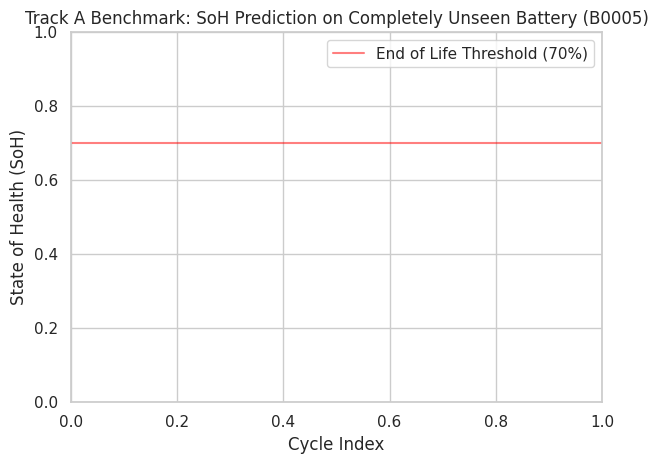

In [14]:
# Draw the Universal Dead Barrier (70% SoH)
plt.axhline(y=0.70, color='red', alpha=0.5, label='End of Life Threshold (70%)')

plt.title(f"Track A Benchmark: SoH Prediction on Completely Unseen Battery ({target_test_battery})")
plt.xlabel("Cycle Index")
plt.ylabel("State of Health (SoH)")
plt.legend()
plt.tight_layout()
plt.show()
